In [1]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import pearsonr

sys.path.insert(0, str(Path('..').resolve().parent))
from config.preprocess_config import T
from evaluate import *

Path('../../figures').mkdir(parents=True, exist_ok=True)


In [2]:
# Plot config
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

C_GEN_CA = '#A8ECFF'
C_GEN_CAFILM = '#38CFEA'
C_REAL = 'tab:blue'
C_NORMAL = 'tab:red'
MODEL_COLORS = {'ca': C_GEN_CA, 'ca-film': C_GEN_CAFILM}
MODEL_LABELS = {'ca': 'CA', 'ca-film': 'CA-Film'}

print("Plot config defined.")

Plot config defined.


In [3]:
"""
Get generated data.
"""

MODEL_DIRS = {
    'ca': Path('../../data/generated/ca'),
    'ca-film': Path('../../data/generated/ca-film'),
}

ALL_FILES = sorted(f.name for f in next(iter(MODEL_DIRS.values())).glob('*.json'))
for model, base_dir in MODEL_DIRS.items():
    model_files = sorted(f.name for f in base_dir.glob('*.json'))
    if model_files != ALL_FILES:
        raise FileNotFoundError(f'{model}: expected {len(ALL_FILES)} files matching ca grid, got {len(model_files)}')

gen_data = {}
for model, base_dir in MODEL_DIRS.items():
    gen_data[model] = {}
    for filename in ALL_FILES:
        with open(base_dir / filename) as f:
            payload = json.load(f)
        samples = np.array(payload['samples'], dtype=np.float64)
        t_tgt = payload['conditions']['trend']
        r_tgt = payload['conditions']['realized_vol']
        # JSON: per-day log returns in decimal (see generate.ipynb scale-back).

        gen_data[model][filename] = {
            'n_samples': samples.shape[0],
            'trend_target': t_tgt,
            'trend_achieved': np.sum(samples * 100, axis=1),
            'rv_target': r_tgt,
            'rv_achieved': np.sum((samples * 100) ** 2, axis=1),
        }

print("Generated data loaded.")


Generated data loaded.


In [4]:
"""
3.1 - Trend adherence.
"""

print(f"{'=' * 25} Trend Adherence {'=' * 26}\n")
trend_pts = {}
for model in MODEL_DIRS:
    targets, mean_achieved = adherence_table('trend', model, gen_data, ALL_FILES)
    trend_pts[model] = (targets, mean_achieved)
    print()


========================= Trend Adherence ==========================

ca                        Target        Mean         Std     |Error|
────────────────────────────────────────────────────────────────────
t-10r100i15v15.json       -10.00      1.9184     27.0757     11.9184
t-10r100i15v25.json       -10.00      2.6695     25.6309     12.6695
t-10r100i350v15.json      -10.00      2.2395     26.5190     12.2395
t-10r100i350v25.json      -10.00      1.4621     26.9009     11.4621
t-10r300i15v15.json       -10.00      2.4486     28.7565     12.4486
t-10r300i15v25.json       -10.00      1.7192     25.9302     11.7192
t-10r300i350v15.json      -10.00      2.5838     27.0304     12.5838
t-10r300i350v25.json      -10.00      2.5262     27.7852     12.5262
t-10r500i15v15.json       -10.00      2.0082     28.4131     12.0082
t-10r500i15v25.json       -10.00      2.3618     30.7214     12.3618
t-10r500i350v15.json      -10.00      1.6893     28.5773     11.6893
t-10r500i350v25.json      -10.00 

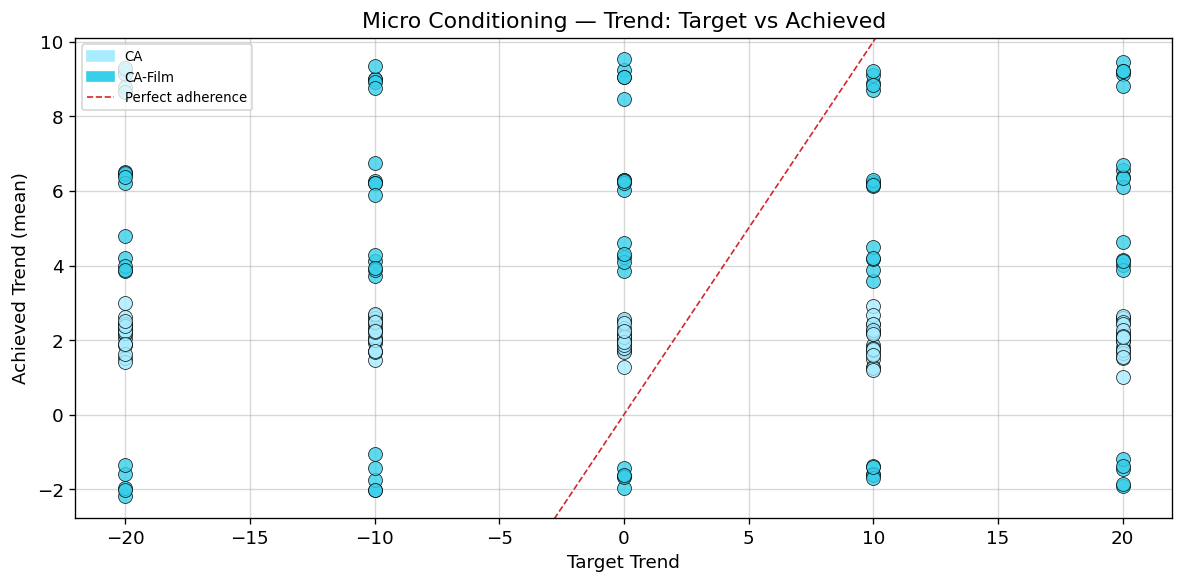

In [5]:
# Configs
fig, ax = plt.subplots(figsize=(10, 5))

# Plot
for model, (targets, mean_achieved) in trend_pts.items():
    ax.scatter(
        targets, mean_achieved,
        color=MODEL_COLORS[model], edgecolors='k', linewidths=0.5,
        s=70, alpha=0.8, zorder=3,
    )

# Plot configs
xlim = ax.get_xlim()
ylim = ax.get_ylim()
lims = [min(xlim[0], ylim[0]), max(xlim[1], ylim[1])] # Line
ax.plot(lims, lims, color=C_NORMAL, linestyle='--', linewidth=1.0, zorder=2)
ax.set_xlim(xlim)
ax.set_xlabel('Target Trend')
ax.set_ylim(ylim)
ax.set_ylabel('Achieved Trend (mean)')
ax.set_title('Micro Conditioning — Trend: Target vs Achieved')
ax.grid(alpha=0.5)
legend_handles = [
    mpatches.Patch(color=MODEL_COLORS[m], label=MODEL_LABELS[m]) for m in MODEL_DIRS
] + [Line2D([0], [0], color=C_NORMAL, linestyle='--', linewidth=1.0, label='Perfect adherence')]
ax.legend(handles=legend_handles, fontsize=8, loc='upper left')

# Show and save
plt.tight_layout()
plt.savefig('../../figures/conditioning_trend.png')
plt.show()


In [6]:
"""
3.2 - Realized volatility adherence.
"""

print(f"{'=' * 25} Realized Vol Adherence {'=' * 26}\n")
rv_pts = {}
for model in MODEL_DIRS:
    targets, mean_achieved = adherence_table('rv', model, gen_data, ALL_FILES)
    rv_pts[model] = (targets, mean_achieved)
    print()


========================= Realized Vol Adherence ==========================

ca                        Target        Mean         Std     |Error|
────────────────────────────────────────────────────────────────────
t-10r100i15v15.json       100.00    656.9371   2739.1739    556.9371
t-10r100i15v25.json       100.00    584.6878   1255.7287    484.6878
t-10r100i350v15.json      100.00    598.2707   1244.3234    498.2707
t-10r100i350v25.json      100.00    662.4671   4073.1912    562.4671
t-10r300i15v15.json       300.00    684.2365   3804.6579    384.2365
t-10r300i15v25.json       300.00    596.7579   1180.2596    296.7579
t-10r300i350v15.json      300.00    610.5142   1364.3804    310.5142
t-10r300i350v25.json      300.00    614.1974   1306.0105    314.1974
t-10r500i15v15.json       500.00    650.2445   1838.7245    150.2445
t-10r500i15v25.json       500.00    639.4991   2783.5870    139.4991
t-10r500i350v15.json      500.00    632.6194   1970.5640    132.6194
t-10r500i350v25.json      

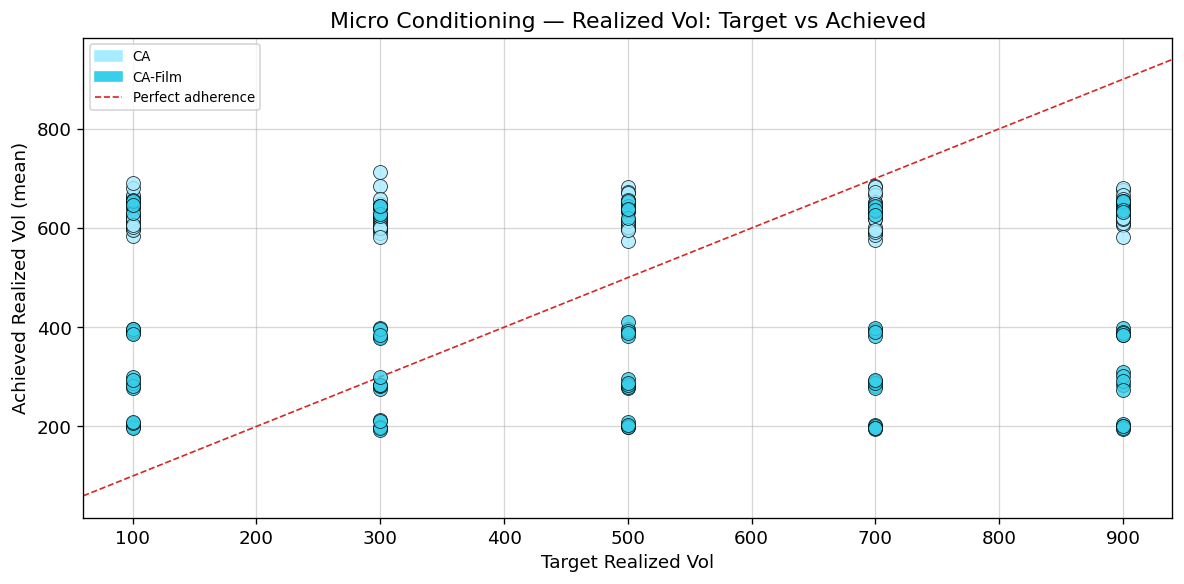

In [8]:
# Configs
fig, ax = plt.subplots(figsize=(10, 5))

# Plot
for model, (targets, mean_achieved) in rv_pts.items():
    ax.scatter(
        targets, mean_achieved,
        color=MODEL_COLORS[model], edgecolors='k', linewidths=0.5,
        s=70, alpha=0.8, zorder=3,
    )

# Plot configs
xlim = ax.get_xlim()
ylim = ax.get_ylim()
lims = [min(xlim[0], ylim[0]), max(xlim[1], ylim[1])] # Line
ax.plot(lims, lims, color=C_NORMAL, linestyle='--', linewidth=1.0, zorder=2)
ax.set_xlim(xlim)
ax.set_xlabel('Target Realized Vol')
ax.set_ylabel('Achieved Realized Vol (mean)')
ax.set_title('Micro Conditioning — Realized Vol: Target vs Achieved')
ax.grid(alpha=0.5)
legend_handles = [
    mpatches.Patch(color=MODEL_COLORS[m], label=MODEL_LABELS[m]) for m in MODEL_DIRS
] + [Line2D([0], [0], color=C_NORMAL, linestyle='--', linewidth=1.0, label='Perfect adherence')]
ax.legend(handles=legend_handles, fontsize=8, loc='upper left')

# Show and save
plt.tight_layout()
plt.savefig('../../figures/conditioning_rv.png')
plt.show()
